# Grasp adaptation — compliance-matched stiffness control

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys
from pathlib import Path

sys.path.insert(0, os.path.join('../'))
from plot_config import draw_radar

OUTPUT_DIR = os.path.join('outputs', 'grasp_adaptation')
OBJECTS    = ['hard_obj', 'soft_obj']
COLORS     = {'hard_obj': '#0072B2', 'soft_obj': '#D55E00'}

def load_latest(obj):
    folder = Path(OUTPUT_DIR)
    if not folder.exists():
        return None
    files = sorted(folder.glob(f'grasp_{obj}*.csv'))
    return pd.read_csv(files[-1]) if files else None

data = {obj: load_latest(obj) for obj in OBJECTS}

## Sensing phase — fingertip displacement per object

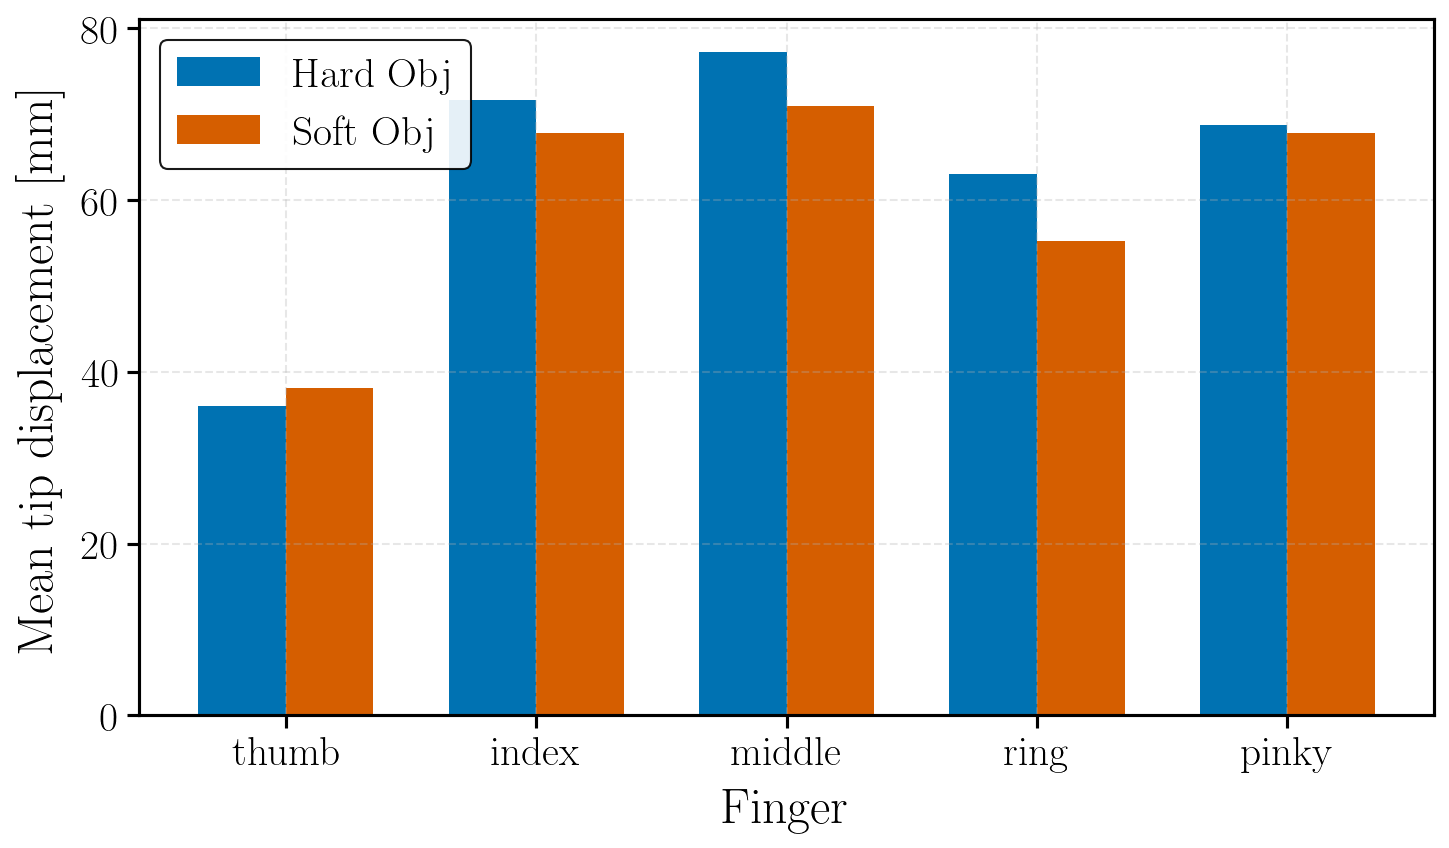

In [14]:
fig, ax = plt.subplots()

FINGERTIPS = ['thumb', 'index', 'middle', 'ring', 'pinky']
x = np.arange(len(FINGERTIPS))
width = 0.35

for i, (obj, color) in enumerate(COLORS.items()):
    df = data[obj]
    if df is None:
        continue
    sense = df[df['phase'] == 'sense']
    means = [sense[f'disp_{f}_mag_m'].mean() * 1e3 for f in FINGERTIPS]
    ax.bar(x + i * width, means, width, label=obj.replace('_', ' ').title(),
           color=color)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(FINGERTIPS)
ax.set_xlabel('Finger')
ax.set_ylabel('Mean tip displacement [mm]')
ax.legend()
fig.tight_layout()
os.makedirs(OUTPUT_DIR, exist_ok=True)
fig.savefig(os.path.join(OUTPUT_DIR, 'sensing_displacement.pdf'), bbox_inches='tight')
plt.show()

## Adapted stiffness — sensing displacement vs k_applied

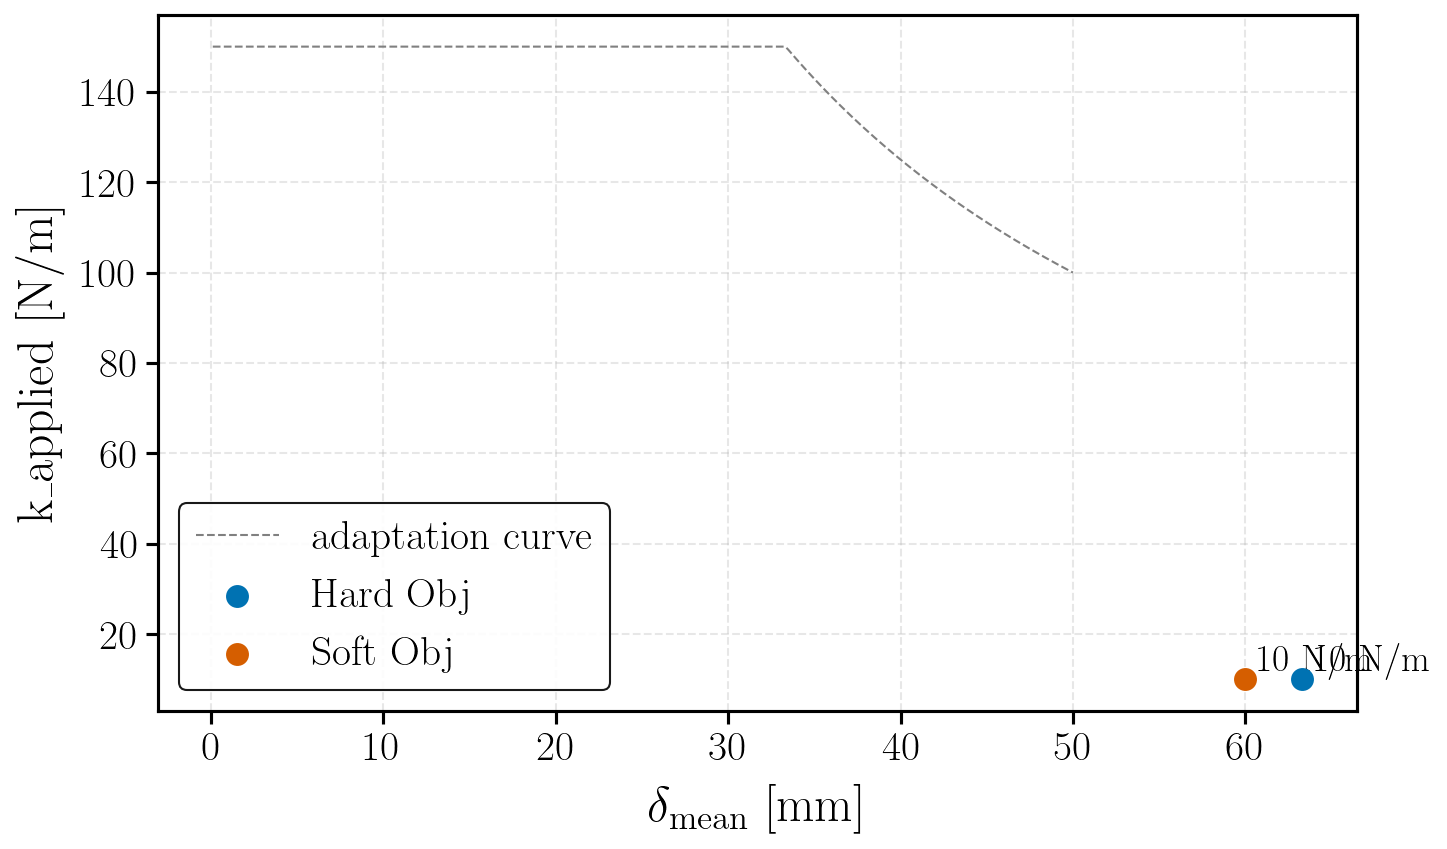

In [15]:
fig, ax = plt.subplots()

# Overlay the adaptation curve k = K_GAIN / delta (clipped to [K_MIN, K_MAX]).
from hand_config import K_GAIN, K_MIN, K_MAX

FINGERTIPS = ['thumb', 'index', 'middle', 'ring', 'pinky']
delta_range = np.linspace(1e-4, 0.05, 300)
k_curve     = np.clip(K_GAIN / delta_range, K_MIN, K_MAX)
ax.plot(delta_range * 1e3, k_curve, color='0.5', lw=1, linestyle='--',
        label='adaptation curve')

for obj, color in COLORS.items():
    df = data[obj]
    if df is None:
        continue
    sense = df[df['phase'] == 'sense']
    delta = float(sense[[f'disp_{f}_mag_m' for f in FINGERTIPS]].mean(axis=1).mean()) * 1e3
    k_app = float(sense['k_applied_Npm'].iloc[-1])
    ax.scatter([delta], [k_app], color=color, zorder=5,
               label=obj.replace('_', ' ').title())
    ax.annotate(f'{k_app:.0f} N/m', (delta, k_app),
                textcoords='offset points', xytext=(6, 4))

ax.set_xlabel(r'$\delta_\mathrm{mean}$ [mm]')
ax.set_ylabel('k_applied [N/m]')
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'adaptation_curve.pdf'), bbox_inches='tight')
plt.show()

## Per-finger object compliance $C_O^f$

$C_O^f = \|\Delta x_f\| / \|\Delta F_f\|$ computed finger-by-finger from the sense → probe finite difference. Soft object → larger compliance per finger.

In [ ]:
fig, ax = plt.subplots()

FINGERTIPS = ['thumb', 'index', 'middle', 'ring', 'pinky']
x = np.arange(len(FINGERTIPS))
width = 0.35

for i, (obj, color) in enumerate(COLORS.items()):
    df = data[obj]
    if df is None:
        continue
    sense = df[df['phase'] == 'sense']
    probe = df[df['phase'] == 'probe']
    co_f = []
    for f in FINGERTIPS:
        tip_cols   = [f'tip_{f}_x_m',      f'tip_{f}_y_m',      f'tip_{f}_z_m']
        force_cols = [f'force_1st_{f}_x_N', f'force_1st_{f}_y_N', f'force_1st_{f}_z_N']
        d_pos = probe[tip_cols].median().to_numpy() - sense[tip_cols].median().to_numpy()
        d_F   = probe[force_cols].median().to_numpy() - sense[force_cols].median().to_numpy()
        nF = np.linalg.norm(d_F)
        co_f.append(np.linalg.norm(d_pos) / nF * 1e3 if nF > 1e-12 else np.nan)
    ax.bar(x + i * width, co_f, width,
           label=obj.replace('_', ' ').title(), color=color)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(FINGERTIPS)
ax.set_xlabel('Finger')
ax.set_ylabel(r'$C_O^f$ [mm/N]')
ax.legend(fontsize='small')
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'compliance_per_finger.pdf'), bbox_inches='tight')
plt.show()

## Contact force at hold

Mean $|F_f|$ per finger during the hold phase (adapted stiffness active). A higher $k_\mathrm{applied}$ on the hard object should produce larger forces.

In [ ]:
fig, ax = plt.subplots()

FINGERTIPS = ['thumb', 'index', 'middle', 'ring', 'pinky']
x = np.arange(len(FINGERTIPS))
width = 0.35

for i, (obj, color) in enumerate(COLORS.items()):
    df = data[obj]
    if df is None:
        continue
    hold = df[df['phase'] == 'hold']
    means = [hold[f'force_1st_{f}_mag_N'].mean() for f in FINGERTIPS]
    stds  = [hold[f'force_1st_{f}_mag_N'].std()  for f in FINGERTIPS]
    ax.bar(x + i * width, means, width, yerr=stds, capsize=3,
           label=obj.replace('_', ' ').title(), color=color)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(FINGERTIPS)
ax.set_xlabel('Finger')
ax.set_ylabel(r'$|F_\mathrm{tip}|$ [N]')
ax.legend(fontsize='small')
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'hold_force.pdf'), bbox_inches='tight')
plt.show()

## Stiffness timeline

$k_{tip}$ over time for both objects (time zero = first logged sample). Shows the full pipeline: gentle → probe → adapted → hold.

In [ ]:
fig, ax = plt.subplots()

for obj, color in COLORS.items():
    df = data[obj]
    if df is None:
        continue
    t = df['time_s'] - df['time_s'].iloc[0]
    ax.plot(t, df['k_tip_Npm'], color=color, lw=1.2,
            label=obj.replace('_', ' ').title())

ax.set_xlabel('Time [s]')
ax.set_ylabel(r'$k_{tip}$ [N/m]')
ax.legend(fontsize='small')
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'stiffness_timeline.pdf'), bbox_inches='tight')
plt.show()

## Hand pose at hold

Motor configuration $q$ at mid-hold for each object. A stiffer adapted stiffness should produce a more closed pose on the hard object.

In [ ]:
import sys
sys.path.insert(0, os.path.join('../'))
from ModelIDHand.hand_viz import plot_hand, _COL

FINGERTIPS_VIZ = ['thumb', 'index', 'middle', 'ring', 'pinky']
_Q_COLS = [f'q_motor_{i}_rad' for i in range(15)]
_STYLE  = dict(linestyle='-', linewidth=4.5, marker='o', markersize=6.0)
_ELEV, _AZIM = 22, 112

objects_with_data = [o for o in COLORS if data[o] is not None]
fig = plt.figure(figsize=(7 * len(objects_with_data), 6))
fig.patch.set_facecolor('white')
axes = []
for i, obj in enumerate(objects_with_data):
    df = data[obj]
    hold = df[df['phase'] == 'hold']
    q    = hold[_Q_COLS].iloc[len(hold) // 2].to_numpy(dtype=np.float64)
    ax3d = fig.add_subplot(1, len(objects_with_data), i + 1, projection='3d')
    plot_hand(q, ax=ax3d, style=_STYLE)
    leg = ax3d.get_legend()
    if leg: leg.remove()
    ax3d.set_xticks([]); ax3d.set_yticks([]); ax3d.set_zticks([])
    for pane in (ax3d.xaxis.pane, ax3d.yaxis.pane, ax3d.zaxis.pane):
        pane.fill = False; pane.set_edgecolor('#d8d8d8')
    ax3d.view_init(elev=_ELEV, azim=_AZIM)
    post = df[df['phase'].isin(['adapt', 'lift', 'hold', 'place'])]
    k_app = float(post['k_applied_Npm'].iloc[0]) if not post.empty else float('nan')
    ax3d.set_title(f"{obj.replace('_', ' ').title()}\n$k_{{applied}}={k_app:.0f}$ N/m",
                   fontsize=14, fontweight='semibold', pad=14)
    axes.append(ax3d)

# sync axes limits
lims = np.array([[a.get_xlim3d(), a.get_ylim3d(), a.get_zlim3d()] for a in axes])
xl = [lims[:, 0, 0].min(), lims[:, 0, 1].max()]
yl = [lims[:, 1, 0].min(), lims[:, 1, 1].max()]
zl = [lims[:, 2, 0].min(), lims[:, 2, 1].max()]
span = max(xl[1]-xl[0], yl[1]-yl[0], zl[1]-zl[0])
cx, cy, cz = sum(xl)/2, sum(yl)/2, sum(zl)/2
for a in axes:
    a.set_xlim3d(cx-span/2, cx+span/2)
    a.set_ylim3d(cy-span/2, cy+span/2)
    a.set_zlim3d(cz-span/2, cz+span/2)

_LEG = [plt.Line2D([0],[0], color=_COL[n], lw=5, label=n.capitalize())
        for n in FINGERTIPS_VIZ]
fig.legend(handles=_LEG, loc='lower center', ncol=5, fontsize=10,
           frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'hold_hand_pose.pdf'), bbox_inches='tight', dpi=300)
plt.show()